##                                Project 3: Gradient Descent with Global CO2 Levels

In [2]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

CO2_data = pd.read_csv('/Users/shaheenhajinurmohamed/Desktop/MATH250FINAL/annual_global_CO2_levels.txt', delimiter='\t')
CO2_data

,Year,CO2Level
0,1940,4.86
1,1941,4.97
2,1942,4.96
3,1943,5.04
4,1944,5.12
...,...,...
80,2020,34.37
81,2021,36.20
82,2022,36.50
83,2023,37.01


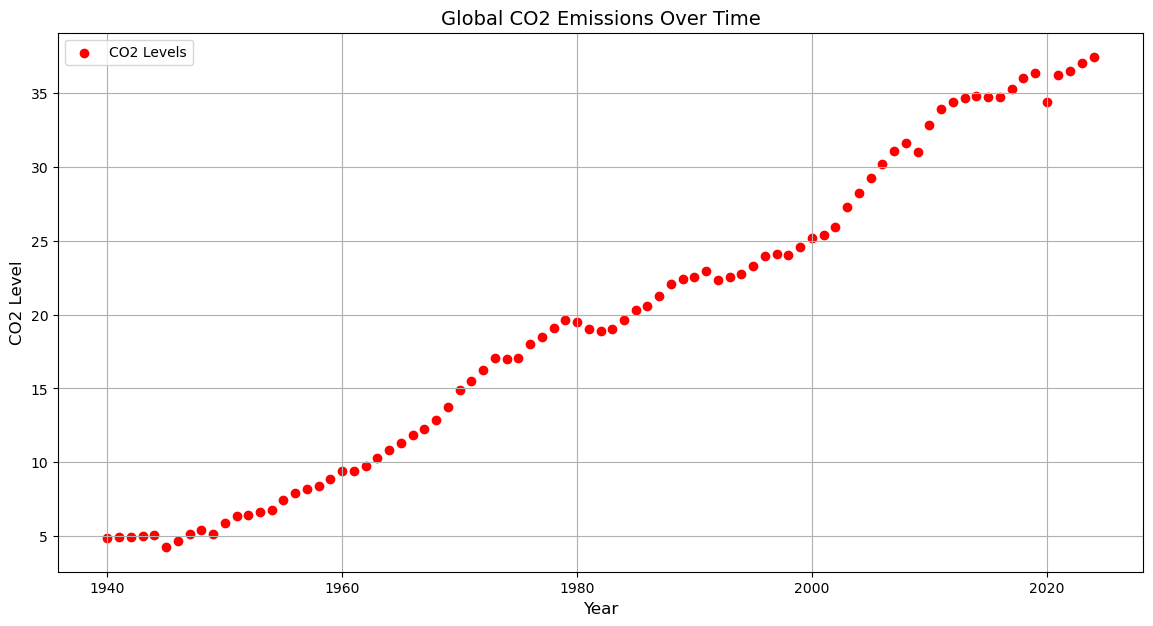

In [3]:
#Plotting graph for visualization. 

plt.figure(figsize=(14, 7))
plt.scatter(CO2_data['Year'], CO2_data['CO2Level'], marker='o', linestyle='-', color='r', label='CO2 Levels')
plt.title('Global CO2 Emissions Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Level', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [4]:
# Normalize X to improve gradient descent performance
X = (CO2_data['Year'].values - np.mean(CO2_data['Year'].values)) / np.std(CO2_data['Year'].values)
y = CO2_data['CO2Level'].values

In [5]:

# Step 1: Split off the test set (10%) - used NOTES FROM PROFESSOR DOCUMENT ON Gradient Descent Process
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Step 2: Split remaining data into training (80%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=0)

# Check the sizes
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")



Training set size: 54
Validation set size: 14
Test set size: 17


## Linear Model y = wx + b

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

learning_rate = 0.1
epochs = 1000

# used professor code from class gradient class -GradientDescent.pylb

def one_step(X: np.ndarray, y: np.ndarray, w: float, b: float, learning_rate: float) -> tuple:
    """Perform one step of gradient descent using MAE loss."""
    m = len(X)
    y_pred = w * X + b

    # Compute residuals and partial derivatives for MAE
    residual = y - y_pred
    dw = -(1 / m) * np.sum(np.sign(residual) * X)
    db = -(1 / m) * np.sum(np.sign(residual))

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b

def gradient_descent(X: np.ndarray, y: np.ndarray, X_val: np.ndarray, y_val: np.ndarray,
                     learning_rate: float, epochs: int, prints: int = 100) -> tuple:
    """Perform gradient descent for linear regression using MAE loss."""
    # Initialize parameters
    w = np.random.randn()  # slope
    b = np.random.randn()  # y-intercept

    # Store losses for tracking progress
    losses = []
    val_losses = []

    for epoch in range(epochs):
        # Perform one step of gradient descent
        w, b = one_step(X, y, w, b, learning_rate)

        # Calculate MAE for training and validation data
        train_loss = np.mean(np.abs(y - (w * X + b)))  #residual calulate ypredictied - yactual
        val_loss = np.mean(np.abs(y_val - (w * X_val + b)))
        
        losses.append(train_loss)
        val_losses.append(val_loss)

        # Print progress at intervals
        if epoch % prints == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
            print(f"w = {w:.4f}, b = {b:.4f}")

    return w, b, losses, val_losses


In [7]:
w, b, losses, val_losses = gradient_descent(X_train, y_train, X_val, y_val, learning_rate, epochs)


Epoch 0: Train Loss = 19.9615, Val Loss = 18.0744
w = -1.5855, b = 0.8239
Epoch 100: Train Loss = 11.4223, Val Loss = 10.2867
w = 2.3356, b = 9.0461
Epoch 200: Train Loss = 3.8840, Val Loss = 3.9458
w = 7.3175, b = 16.1239
Epoch 300: Train Loss = 1.0758, Val Loss = 0.8018
w = 10.5001, b = 19.2869
Epoch 400: Train Loss = 1.0604, Val Loss = 0.9036
w = 10.7160, b = 19.1054
Epoch 500: Train Loss = 1.0604, Val Loss = 0.9036
w = 10.7157, b = 19.1054
Epoch 600: Train Loss = 1.0604, Val Loss = 0.9035
w = 10.7154, b = 19.1054
Epoch 700: Train Loss = 1.0604, Val Loss = 0.9034
w = 10.7151, b = 19.1054
Epoch 800: Train Loss = 1.0604, Val Loss = 0.9033
w = 10.7148, b = 19.1054
Epoch 900: Train Loss = 1.0604, Val Loss = 0.9033
w = 10.7145, b = 19.1054


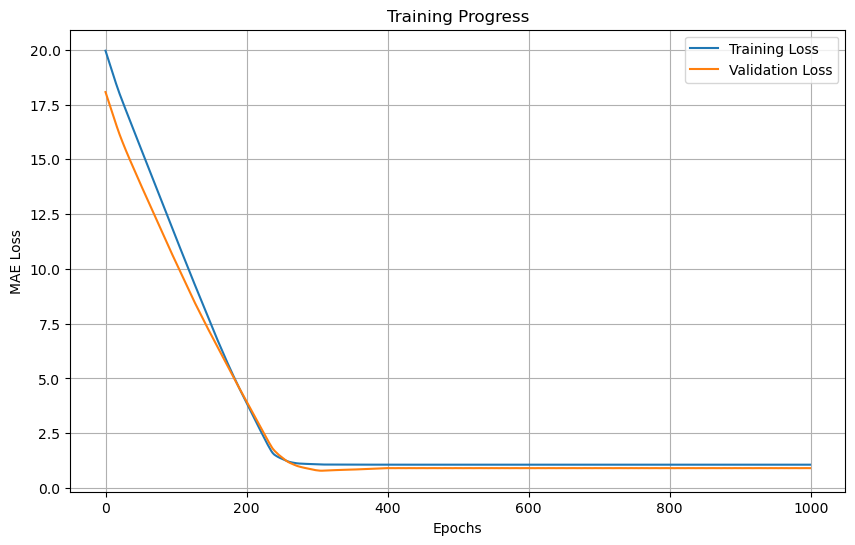

In [8]:
#plotting the Error/Loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.title('Training Progress')
plt.legend()
plt.grid()
plt.show()



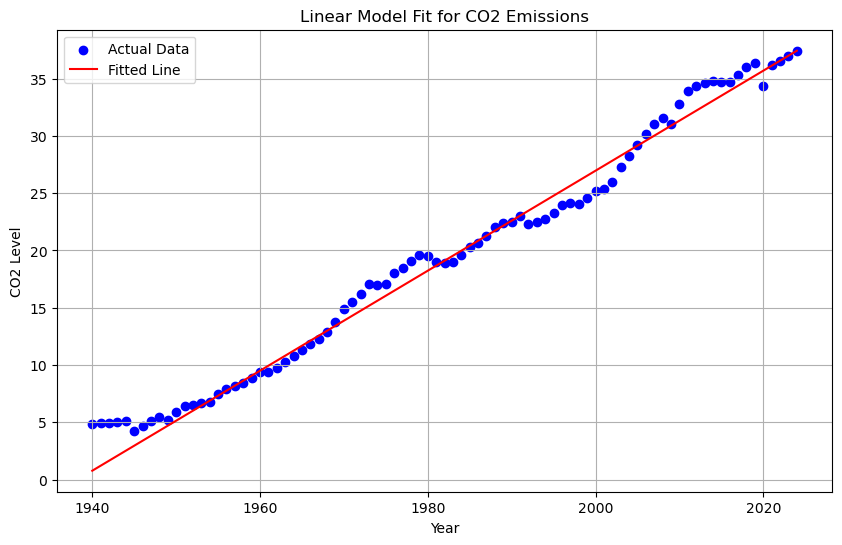

In [9]:
# Plot fitted model
plt.figure(figsize=(10, 6))
plt.scatter(CO2_data['Year'], y, color='blue', label='Actual Data')
plt.plot(CO2_data['Year'], w * X + b, color='red', label='Fitted Line')
plt.title('Linear Model Fit for CO2 Emissions')
plt.xlabel('Year')
plt.ylabel('CO2 Level')
plt.legend()
plt.grid()
plt.show()

## Quadratic Model y= ax^2 + bx + c

In [10]:
learning_rate = 0.1
epochs = 1200

def one_step_quad(X: np.ndarray, y: np.ndarray, a: float, b: float, c:float, learning_rate: float) -> tuple:
    """Perform one step of gradient descent using MAE loss."""
    m = len(X)
    y_pred = a * (X**2) + b * X + c

    # Compute residuals and partial derivatives for MAE
    residual = y - y_pred
    da = -(1 / m) * np.sum(np.sign(residual) * (X**2))
    db = -(1 / m) * np.sum(np.sign(residual) * X)
    dc = -(1 / m) * np.sum(np.sign(residual))

    # Update parameters
    a = a - learning_rate * da
    b = b - learning_rate * db
    c = c - learning_rate * dc

    return a, b, c



def gradient_descent_poly(X: np.ndarray, y: np.ndarray, X_val: np.ndarray, y_val: np.ndarray,
                          learning_rate: float, epochs: int, prints: int = 100) -> tuple:
    """Perform gradient descent for a quadratic polynomial using MAE loss."""
    # Initialize parameters
    a = np.random.randn()  # Quadratic coefficient
    b = np.random.randn()  # Linear coefficient
    c = np.random.randn()  # Intercept

    # Store losses
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Perform one step of gradient descent
        a, b, c = one_step_quad(X, y, a, b, c, learning_rate)

        # Calculate MAE for training and validation data
        train_loss = np.mean(np.abs(y - (a * (X**2) + b * X + c)))
        val_loss = np.mean(np.abs(y_val - (a * (X_val**2) + b * X_val + c)))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Print progress
        if epoch % prints == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
            print(f"a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")

    return a, b, c, train_losses, val_losses



In [11]:
a, b, c, train_losses_poly, val_losses_poly = gradient_descent_poly(X_train, y_train, X_val, y_val, learning_rate, epochs)

Epoch 0: Train Loss = 19.5173, Val Loss = 17.7023
a = 0.2184, b = -1.2279, c = 1.0001
Epoch 100: Train Loss = 9.4036, Val Loss = 8.6645
a = 4.4752, b = 3.9565, c = 8.2853
Epoch 200: Train Loss = 3.7164, Val Loss = 3.9445
a = 4.6039, b = 8.9387, c = 13.2631
Epoch 300: Train Loss = 1.1996, Val Loss = 1.7662
a = 1.9513, b = 10.5511, c = 17.0001
Epoch 400: Train Loss = 0.9655, Val Loss = 1.1691
a = 1.0617, b = 10.5721, c = 18.0260
Epoch 500: Train Loss = 0.9452, Val Loss = 1.0157
a = 0.8642, b = 10.6254, c = 18.3631
Epoch 600: Train Loss = 0.9435, Val Loss = 0.9819
a = 0.8288, b = 10.6412, c = 18.4409
Epoch 700: Train Loss = 0.9434, Val Loss = 0.9808
a = 0.8250, b = 10.6421, c = 18.4409
Epoch 800: Train Loss = 0.9434, Val Loss = 0.9817
a = 0.8283, b = 10.6397, c = 18.4409
Epoch 900: Train Loss = 0.9434, Val Loss = 0.9807
a = 0.8245, b = 10.6406, c = 18.4409
Epoch 1000: Train Loss = 0.9434, Val Loss = 0.9816
a = 0.8277, b = 10.6382, c = 18.4409
Epoch 1100: Train Loss = 0.9435, Val Loss = 0.

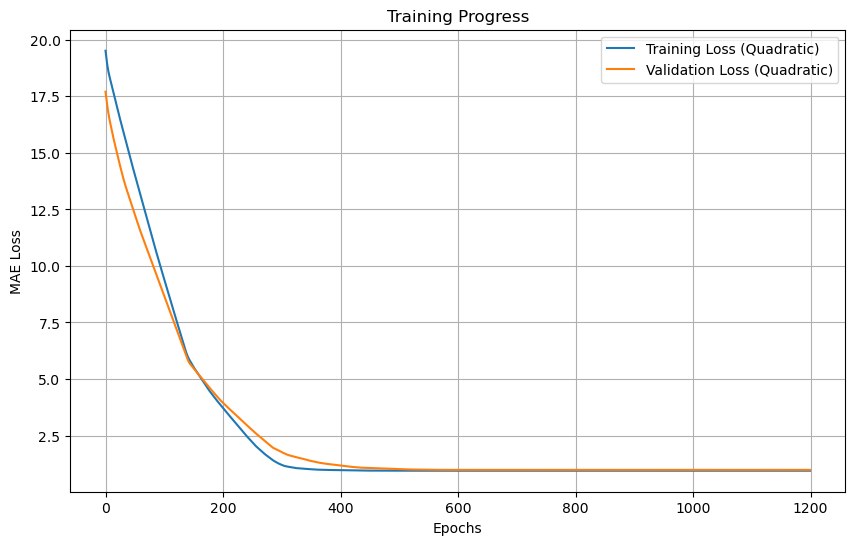

In [12]:
#plotting the Error/Loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses_poly, label='Training Loss (Quadratic)')
plt.plot(val_losses_poly, label='Validation Loss (Quadratic)')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.title('Training Progress')
plt.legend()
plt.grid()
plt.show()

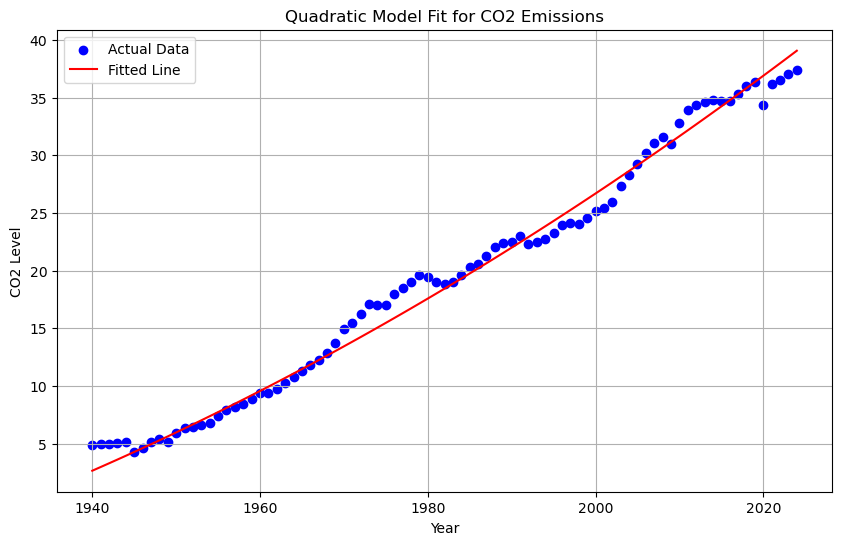

In [13]:
# Plot fitted model
plt.figure(figsize=(10, 6))
plt.scatter(CO2_data['Year'], y, color='blue', label='Actual Data')
plt.plot(CO2_data['Year'],a * (X**2) + b * X + c, color='red', label='Fitted Line')
plt.title('Quadratic Model Fit for CO2 Emissions')
plt.xlabel('Year')
plt.ylabel('CO2 Level')
plt.legend()
plt.grid()
plt.show()

## Exponential Model 

In [14]:
import numpy as np
import matplotlib.pyplot as plt

learning_rate = 0.01
epochs = 1000


# Step 1: Define one step of gradient descent for the exponential model
def one_step_expo(X: np.ndarray, y: np.ndarray, d: float, e: float, f: float, learning_rate: float) -> tuple:
    """Perform one step of gradient descent for an exponential model using MAE loss."""
    m = len(X)
    y_pred = d * np.exp(e * X) + f

    # Compute residuals and partial derivatives
    residual = y - y_pred
    dd = -(1 / m) * np.sum(np.sign(residual) * np.exp(e * X))  # Partial derivative w.r.t. d
    de = -(1 / m) * np.sum(np.sign(residual) * (d * np.exp(e * X) * X))  # Partial derivative w.r.t. e
    df = -(1 / m) * np.sum(np.sign(residual))  # Partial derivative w.r.t. f

    # Update parameters
    d = d - learning_rate * dd
    e = e - learning_rate * de
    f = f - learning_rate * df

    return d, e, f

# Step 2: Define the gradient descent function for the exponential model
def gradient_descent_expo(X: np.ndarray, y: np.ndarray, X_val: np.ndarray, y_val: np.ndarray,
                          learning_rate: float, epochs: int, prints: int = 100) -> tuple:
    """Perform gradient descent for an exponential model using MAE loss."""
    # Initialize parameters
    d = np.random.randn()  # Scaling parameter
    e = np.random.randn()  # Growth/decay rate
    f = np.random.randn()  # Intercept

    # Store losses
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Perform one step of gradient descent
        d, e, f = one_step_expo(X, y, d, e, f, learning_rate)

        # Calculate MAE for training and validation data
        train_loss = np.mean(np.abs(y - (d * np.exp(e * X) + f)))
        val_loss = np.mean(np.abs(y_val - (d * np.exp(e * X_val) + f)))
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Print progress
        if epoch % prints == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
            print(f"d = {d:.4f}, e = {e:.4f}, f = {f:.4f}")

    return d, e, f, train_losses, val_losses

In [15]:
d, e, f, train_losses_expo, val_losses_expo = gradient_descent_expo(X_train, y_train, X_val, y_val, learning_rate, epochs)

Epoch 0: Train Loss = 24.3880, Val Loss = 22.8677
d = -0.8501, e = -0.3411, f = -2.9100
Epoch 100: Train Loss = 22.3561, Val Loss = 20.7716
d = 0.1610, e = -0.2686, f = -1.9100
Epoch 200: Train Loss = 20.2781, Val Loss = 18.6039
d = 1.1802, e = -0.4339, f = -0.9100
Epoch 300: Train Loss = 18.4157, Val Loss = 16.5642
d = 2.0299, e = -0.5748, f = -0.0111
Epoch 400: Train Loss = 17.0129, Val Loss = 15.2800
d = 2.7799, e = -0.2355, f = 0.8377
Epoch 500: Train Loss = 14.1684, Val Loss = 13.0095
d = 3.7379, e = 0.5697, f = 1.7829
Epoch 600: Train Loss = 7.7952, Val Loss = 7.2379
d = 4.6925, e = 1.3325, f = 2.6255
Epoch 700: Train Loss = 6.5070, Val Loss = 6.0520
d = 5.4826, e = 1.2112, f = 3.4307
Epoch 800: Train Loss = 5.4516, Val Loss = 5.0163
d = 6.2189, e = 1.1195, f = 4.1400
Epoch 900: Train Loss = 4.7129, Val Loss = 4.2964
d = 6.8781, e = 1.0397, f = 4.6848


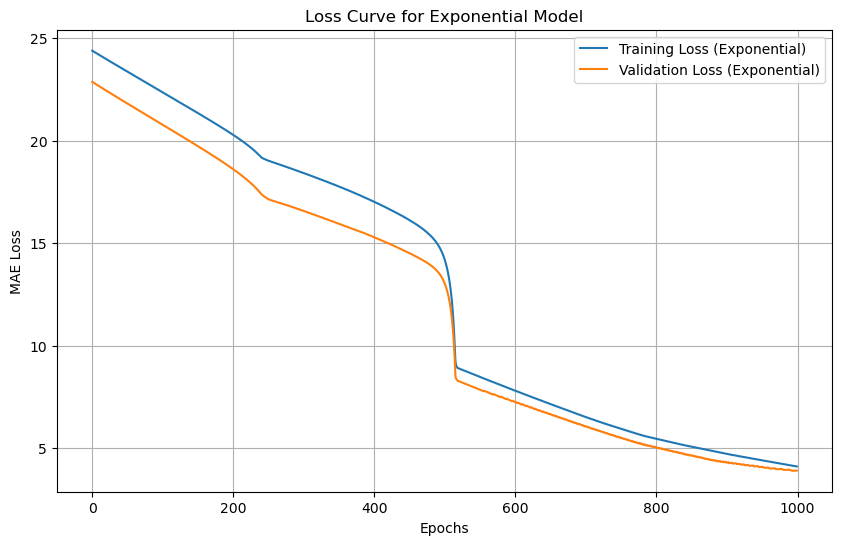

In [16]:
# Step 4: Plot Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses_expo, label='Training Loss (Exponential)')
plt.plot(val_losses_expo, label='Validation Loss (Exponential)')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.title('Loss Curve for Exponential Model')
plt.legend()
plt.grid()
plt.show()

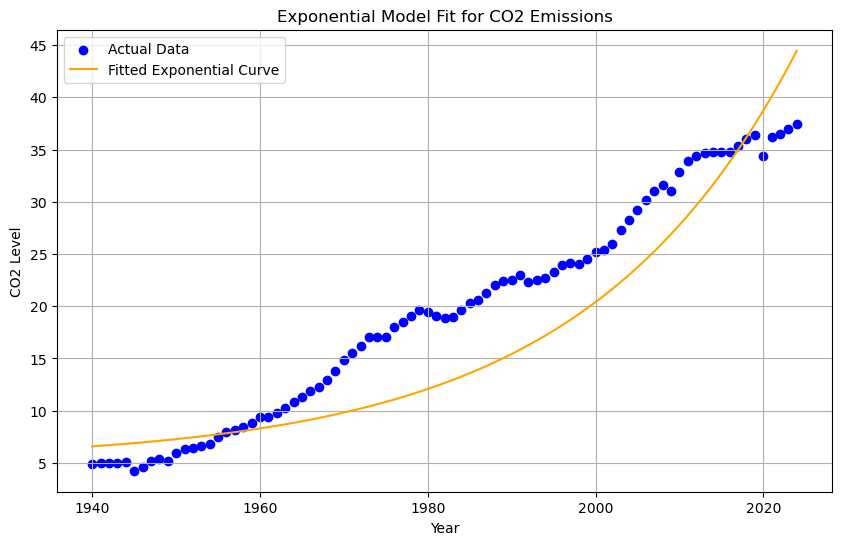

In [17]:
# Step 5: Plot Exponential Model with Fitted Line
y_pred_expo = d * np.exp(e * X) + f  

plt.figure(figsize=(10, 6))
plt.scatter(CO2_data['Year'], y, color='blue', label='Actual Data')
plt.plot(CO2_data['Year'], y_pred_expo, color='orange', label='Fitted Exponential Curve')
plt.title('Exponential Model Fit for CO2 Emissions')
plt.xlabel('Year')
plt.ylabel('CO2 Level')
plt.legend()
plt.grid()
plt.show()